# DSCI Final Project

https://github.com/jacktionc/DSCI235-student-alcohol-consumption-project

### Introduction
In America there is common trend of underage drinking among high school and college age students.The dataset I have found was taken from 2005-2008 from highschool age students in Portugal when the legal drinking age was 16. I will analyze the underlying academic and personal trends of individuals who consume low and high amounts of alcohol during their academic career. This topic has always been of great interest to me due to the past experiences of some of my close friends. Therefore, I will primarily be comparing the features in this data with their drinking habits and looking for any connections.

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

The data consists of surveys given to students enrolled in 2 classes, Math and Portuguese. I attempted to merge the two datasets because in their description it was mentioned that there were around 300 students that appeared in both classes. I attempted a merge based on matching answers in stable student features but ultimately found data inconsistencies. Therefore, I will be doing a parallel comparison of the datasets.

In [77]:
math = pd.read_csv('student-mat.csv')
por = pd.read_csv('student-por.csv')

One of my areas of exploration is the influence of drinking on grades. These datasets separate student drinking into two categories, Dalc(weekday drinking) and Walc(Weekend drinking). However, it would be useful for later comparisons to create column that represents the total drinking a student does.

In [78]:

print("Math dataset:")
print("Dalc vs G3:", math['Dalc'].corr(math['G3']))
print("Walc vs G3:", math['Walc'].corr(math['G3']))

print("\nPortuguese dataset:")
print("Dalc vs G3:", por['Dalc'].corr(por['G3']))
print("Walc vs G3:", por['Walc'].corr(por['G3']))

Math dataset:
Dalc vs G3: -0.05466004056673591
Walc vs G3: -0.05193932374224621

Portuguese dataset:
Dalc vs G3: -0.20471939724815674
Walc vs G3: -0.17661887420966438


There is a very similar correlation between the Dalc and Walc categories when compared to the G3 scores. Therefore, I will combine them into a new column alc_total.  It is also worth mentioning that the grade columns (G1,G2,G3) are representative of Portugal's education structure where each school year is broken up into 2 periods with the last value (G3) being the student's final average grade for that year.

In [79]:
math['alc_total'] = math['Dalc'] + math['Walc']
por['alc_total'] = por['Dalc'] + por['Walc']

I'll begin by looking at the overall distribution of the total drinking among both classes.

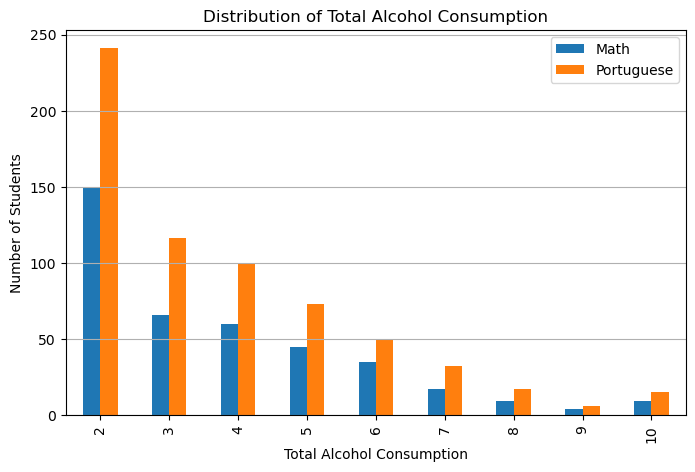

In [80]:
pd.DataFrame({
    'Math': math['alc_total'].value_counts().sort_index(),
    'Portuguese': por['alc_total'].value_counts().sort_index()
}).plot(kind='bar', figsize=(8,5))

plt.title('Distribution of Total Alcohol Consumption')
plt.xlabel('Total Alcohol Consumption')
plt.ylabel('Number of Students')
plt.grid(axis='y')
plt.show()

The vast majority of students seem to fall within the lower to mid range. This tells me that while high alcohol consumption is present, it is not typical behavior. This may limit the overall affects alcohol has on academic performance

### Exploring How Social Activity Affects Consumption

The first thing I wanted to investigate was social interaction. Drinking is an inherently social activity, so I expect this to be a strong predictor for consumption

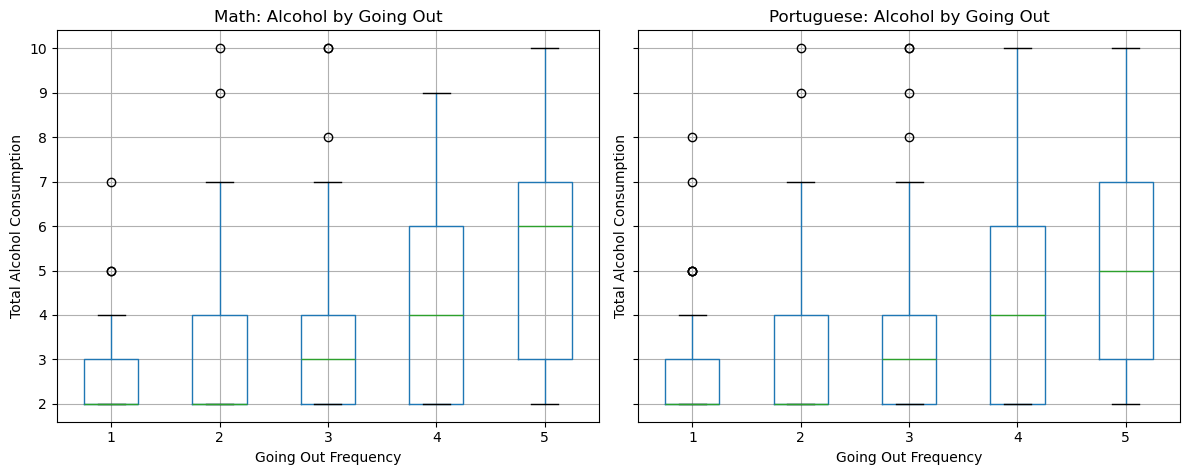

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)

math.boxplot(column='alc_total', by='goout', ax=ax[0])
por.boxplot(column='alc_total', by='goout', ax=ax[1])

ax[0].set_title('Math: Alcohol by Going Out')
ax[1].set_title('Portuguese: Alcohol by Going Out')
for axis in ax:
    axis.set_xlabel('Going Out Frequency')
    axis.set_ylabel('Total Alcohol Consumption')

plt.suptitle('')
plt.tight_layout()
plt.show()

This is somewhat unsurprising in that the students that go out the most also drink more on average. However, there still seems to be some more introverted outliers who drink more heavily through the week.

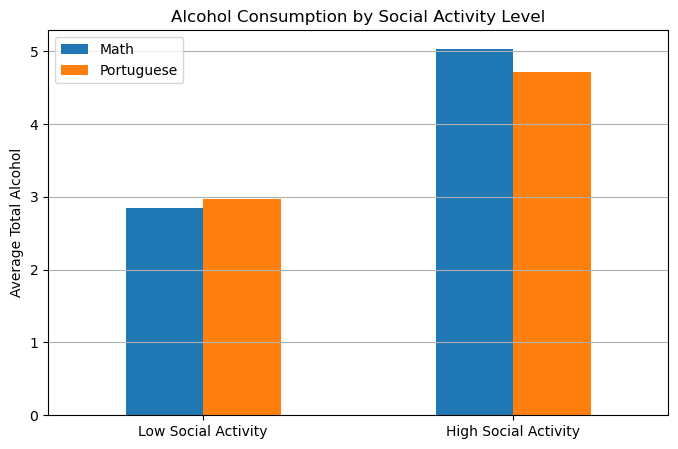

In [82]:
social_means = pd.DataFrame({
    'Math': [math.loc[(math['goout'] <= 2) & (math['freetime'] <= 2), 'alc_total'].mean(), math.loc[(math['goout'] >= 4) & (math['freetime'] >= 4), 'alc_total'].mean()],
    'Portuguese': [por.loc[(por['goout'] <= 2) & (por['freetime'] <= 2), 'alc_total'].mean(), por.loc[(por['goout'] >= 4) & (por['freetime'] >= 4), 'alc_total'].mean()]
}, index=['Low Social Activity', 'High Social Activity'])

social_means.plot(kind='bar', figsize=(8,5))
plt.title('Alcohol Consumption by Social Activity Level')
plt.ylabel('Average Total Alcohol')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

This confirms to me that more social students tend to drink more than less social ones. This can imply that alcohol consumption is more closely related to lifestyle choices rather than purely individual factors.

### Personal

Despite previous results, I'm still curious how much personal factors like family relationship and health play a role in consumption levels.


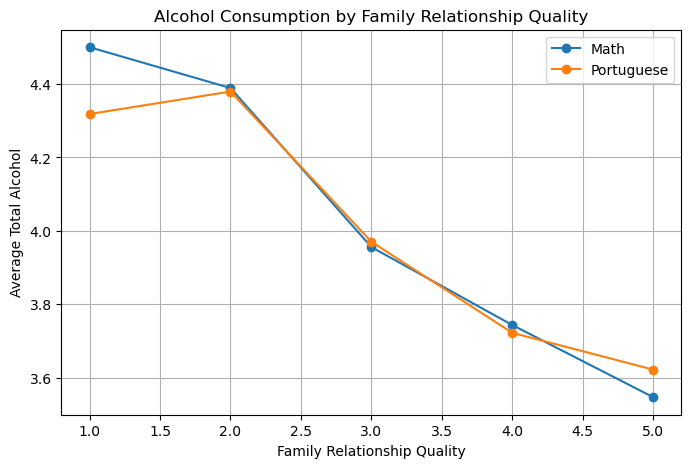

In [83]:
pd.DataFrame({
    'Math': math.groupby('famrel')['alc_total'].mean(),
    'Portuguese': por.groupby('famrel')['alc_total'].mean()
}).plot(marker='o', figsize=(8,5))

plt.title('Alcohol Consumption by Family Relationship Quality')
plt.xlabel('Family Relationship Quality')
plt.ylabel('Average Total Alcohol')
plt.grid(True)
plt.show()

The graph shows that students with a better family relationship tend to drink less overall but only minimally. This could imply that a healthy family environment and support system can act as a protective factor against high consumption. This also lines up with my own experiences.

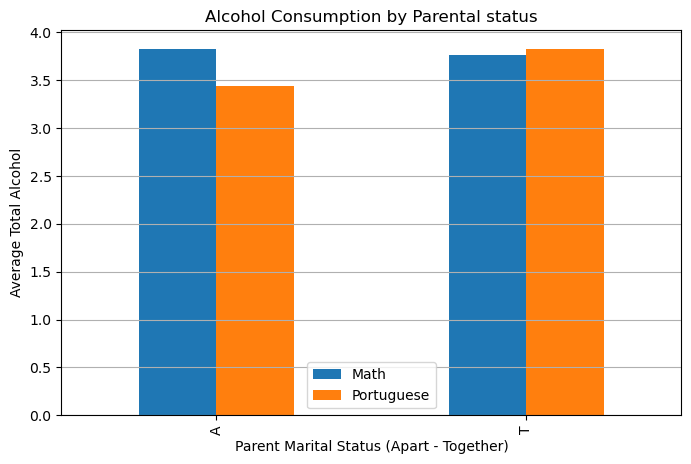

In [106]:
pd.DataFrame({
    'Math': math.groupby('Pstatus')['alc_total'].mean(),
    'Portuguese': por.groupby('Pstatus')['alc_total'].mean()
}).plot(kind='bar', figsize=(8,5))

plt.title('Alcohol Consumption by Parental status')
plt.xlabel('Parent Marital Status (Apart - Together)')
plt.ylabel('Average Total Alcohol')
plt.grid(axis='y')
plt.show()

There's very little difference between the drinking habbits of students based on parental status. This tells me that it's not a very predictive feature of this dataset and that the quality of the parent-student relationship holds more importance.

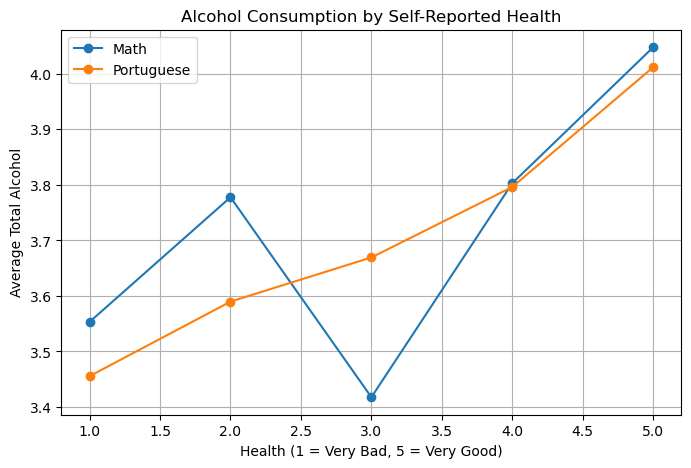

In [85]:
pd.DataFrame({
    'Math': math.groupby('health')['alc_total'].mean(),
    'Portuguese': por.groupby('health')['alc_total'].mean()
}).plot(marker='o', figsize=(8,5))

plt.title('Alcohol Consumption by Self-Reported Health')
plt.xlabel('Health (1 = Very Bad, 5 = Very Good)')
plt.ylabel('Average Total Alcohol')
plt.grid(True)
plt.show()

Moving to an even more individual analysis, I plotted the consumption levels of unhealthy-healthy students. Interestingly enough, healthy students seem to consume more alcohol. This suggests that healthy students likely engage in more social activities which was shown previously to increase consumption. It also indicates that low health is not a driver for alcohol consumption.

I want to examine how academic performance can tie into these health/consumption statistics above by grouping them into bins.

In [86]:
math['health_group'] = pd.cut(math['health'], [0,3,5], labels=['Unhealthy','Healthy'])
por['health_group'] = pd.cut(por['health'], [0,3,5], labels=['Unhealthy','Healthy'])
math['alc_level'] = pd.cut(math['alc_total'], [1,3,6,10], labels=['Low','Medium','High'])
por['alc_level'] = pd.cut(por['alc_total'], [1,3,6,10], labels=['Low','Medium','High']) 

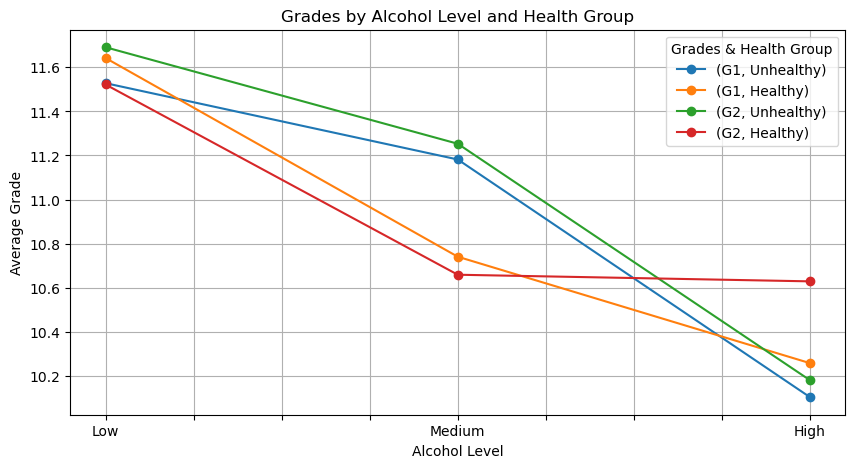

In [87]:
combined = pd.concat([math, por], ignore_index=True)
health_grades = combined.groupby(['alc_level','health_group'])[['G1','G2']].mean()

health_grades.unstack('health_group').plot(marker='o', figsize=(10,5))
plt.title('Grades by Alcohol Level and Health Group')
plt.xlabel('Alcohol Level')
plt.ylabel('Average Grade')
plt.legend(title='Grades & Health Group')
plt.grid(True)
plt.show()

This clearly shows that the grade averages trend downwards the more alcohol a student consumes, regardless of health. However, healthy students tend to maintain slightly better performance across all consumption levels. This indicates that maintaining a healthy lifestyle can mitigate some of the negative effects of alcohol.

# Academic

I will dive further into how alcohol usage can affect various academic factors. I'll start by analyzing how alcohol consumption can affect grade consistency 

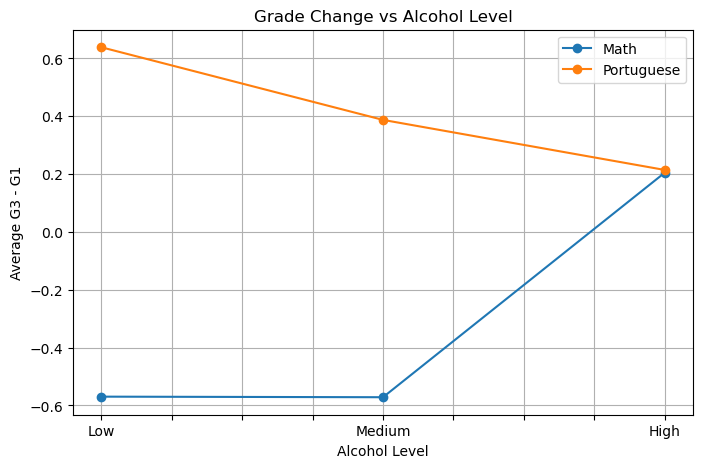

In [94]:
por['grade_change'] = por['G3'] - por['G1']
math['grade_change'] = math['G3'] - math['G1']
pd.DataFrame({
    'Math': math.groupby('alc_level')['grade_change'].mean(),
    'Portuguese': por.groupby('alc_level')['grade_change'].mean()
}).plot(marker='o', figsize=(8,5))

plt.title("Grade Change vs Alcohol Level")
plt.ylabel("Average G3 - G1")
plt.xlabel("Alcohol Level")
plt.grid(True)
plt.show()

In the Portuguese class, grades suffer as alcohol consumption increases showing a negative relationship. However, the opposite relationship is shown for the Math class with high consumption students not experiencing the same decline. This could indicate that the impact of alcohol can vary between school subjects.

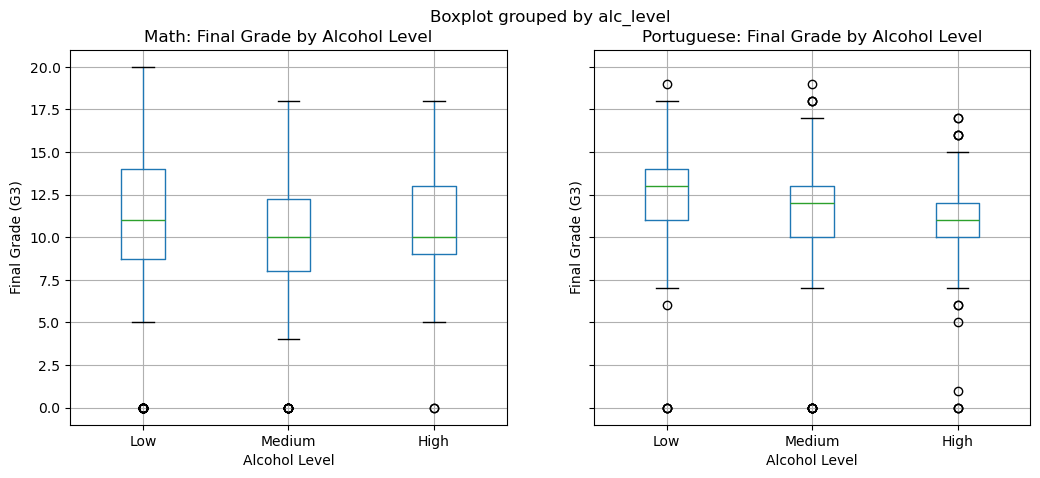

In [88]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)

math.boxplot(column='G3', by='alc_level', ax=ax[0])
por.boxplot(column='G3', by='alc_level', ax=ax[1])

ax[0].set_title('Math: Final Grade by Alcohol Level')
ax[1].set_title('Portuguese: Final Grade by Alcohol Level')
for axis in ax:
    axis.set_xlabel('Alcohol Level')
    axis.set_ylabel('Final Grade (G3)')

plt.show()

Looking further into the distribution of final grades across consumption levels, we can see a slight downward shift in median grade as consumption increases. Also, higher consumption groups show greater variability in performance. This can imply that while alcohol consumption doesn't determine academic success, higher consumption can reduce academic performance and consistency.

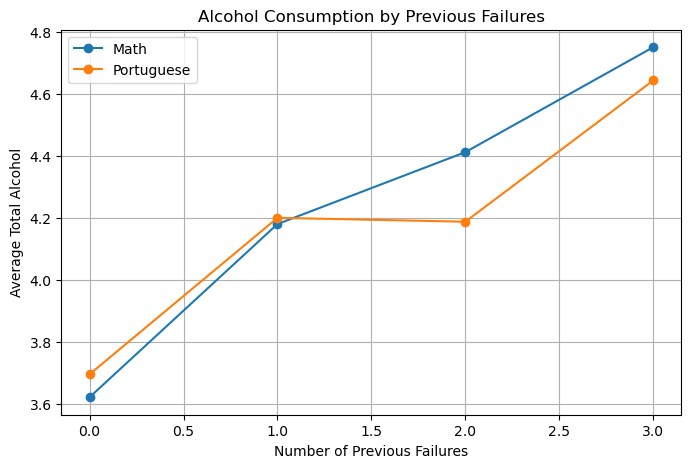

In [89]:
pd.DataFrame({
    'Math': math.groupby('failures')['alc_total'].mean(),
    'Portuguese': por.groupby('failures')['alc_total'].mean()
}).plot(marker='o', figsize=(8,5))

plt.title('Alcohol Consumption by Previous Failures')
plt.xlabel('Number of Previous Failures')
plt.ylabel('Average Total Alcohol')
plt.grid(True)
plt.show()

There's a steady increase in consumption as the number of past failures rises. This indicates that there may be a relationship between academic struggle and higher alcohol use. However, it isn't clear if struggling students tend to resort to alcohol or if high alcohol consumption leads to academic struggle. 

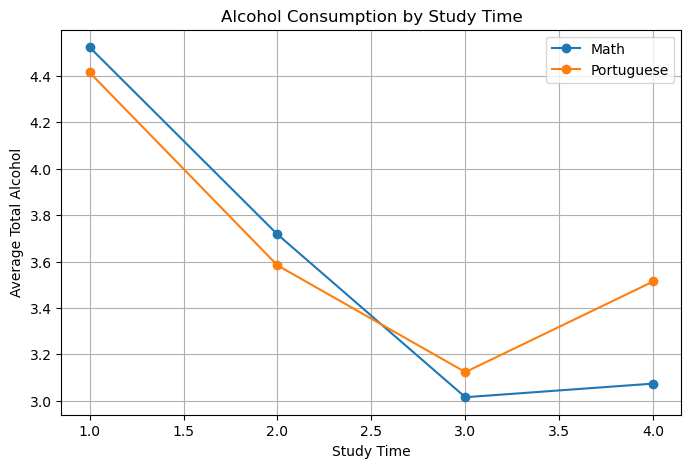

In [91]:
pd.DataFrame({
    'Math': math.groupby('studytime')['alc_total'].mean(),
    'Portuguese': por.groupby('studytime')['alc_total'].mean()
}).plot(marker='o', figsize=(8,5))

plt.title('Alcohol Consumption by Study Time')
plt.xlabel('Study Time')
plt.ylabel('Average Total Alcohol')
plt.grid(True)
plt.show()

When comparing study time to consumption, there's a general decrease in consumption as study time increases. This is especially apparent at low study times.

### Conclusion

It seems that overall, social activity was the highest predictor in student alcohol consumption. While higher consumption is associated with slightly lower final grades and reduced improvement overtime, it is not the defining factor of success in students. However, there was data to support there is a correlation between high alcohol consumption and academic struggle but it's unclear which direction this relationship flows. 

Students that were able to maintain strong family relationships tended to drink less overall. If alcohol consumption is in fact associated with academic struggle, I find that makes it even more important that struggling students are encouraged and enabled to be surrounded by a support system they trust to help mitigate that struggle.